
Hasil retrieval (paling mirip ke kurang mirip):
Rank 1: chelsea (Dist: 0.000)
Rank 2: coins (Dist: 0.288)
Rank 3: coffee (Dist: 0.359)
Rank 4: astronaut (Dist: 0.461)
Rank 5: camera (Dist: 0.602)


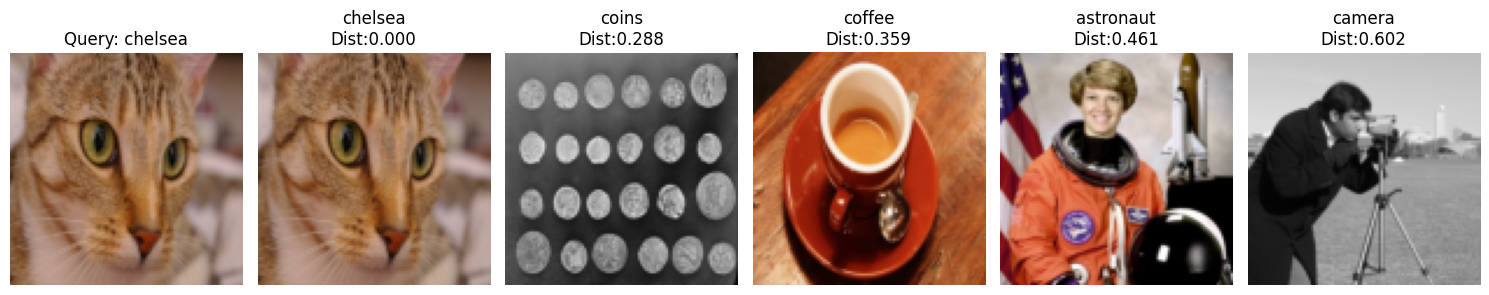

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    img = image
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_uint8 = img_as_ubyte(img)
    hr, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0,256))
    hg, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0,256))
    hb, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0,256))
    h = np.concatenate((hr, hg, hb)).astype(float)
    s = h.sum()
    if s>0:
        h /= s
    return h

# Siapkan database
image_db_names = ['astronaut','camera','coffee','coins','chelsea']
db_images = []
db_hists = []
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100,100), anti_aliasing=True)
        db_images.append(img_resized)
        db_hists.append(calculate_rgb_histogram(img_resized))
    except Exception as e:
        print(f"Gagal muat {name}: {e}")

# Query
query_idx = image_db_names.index('chelsea')
query_hist = db_hists[query_idx]

dists = [distance.cosine(query_hist, h) for h in db_hists]
sorted_idx = np.argsort(dists)

# Tampilkan
fig, axes = plt.subplots(1, len(db_images)+1, figsize=(15,3))
axes[0].imshow(db_images[query_idx]); axes[0].set_title('Query: chelsea'); axes[0].axis('off')
print('\nHasil retrieval (paling mirip ke kurang mirip):')
for i, idx in enumerate(sorted_idx):
    axes[i+1].imshow(db_images[idx]); axes[i+1].set_title(f"{image_db_names[idx]}\nDist:{dists[idx]:.3f}"); axes[i+1].axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Dist: {dists[idx]:.3f})")
plt.tight_layout(); plt.show()

Tugas Lanjutan:
Amati urutan citra hasil retrieval. Apakah citra yang secara visual mirip dengan query (berdasarkan warna dominan karena kita menggunakan histogram warna) muncul di peringkat atas (jarak terkecil)? Seberapa baik histogram warna sebagai fitur untuk CBIR dalam kasus ini?